# Multiple curve plotting and fitting

In this example, we will demonstrate how to plot and fit multiple curves using the `ramanpl` library. This is particularly useful for analyzing Raman and photoluminescence spectra from 2D materials. 

## Raman example
In the following example, we will demonstrate the plotting of WS2 Raman spectra collected from different morphologies fabricated under various temperature conditions.

Expt setting:
- Sampling site: on different WS2 morphology fabricated under different CVD conditions
- Exposure time: 1s
- Laser Power: 1%
- magnification: 100x
- Accumulation: 3
- Laser setting: central $\lambda$ = 520 cm^-1 ; laser = `532`nm ; grating: 1800 vis

### Example of quick multi-plotting

First is the overlay plot of multiple spectra:

```python
        from ramanpl.batch import load_spectra, plot_overlay

        files = [
            "path/to/point1.txt",
            "path/to/point2.txt",
            "path/to/point3.txt",
            "path/to/point4.txt",
        ]

        specs = load_spectra(files, axis="wavenumber")  # or axis="energy" for PL data
        fig, ax = plot_overlay(specs, 
        normalise="max", # options: if set "none", no normalisation
        title="Overlay comparison", 
        xlim=(200, 800)         # set x-axis limits, or x_range=(200, 800)
        )
```

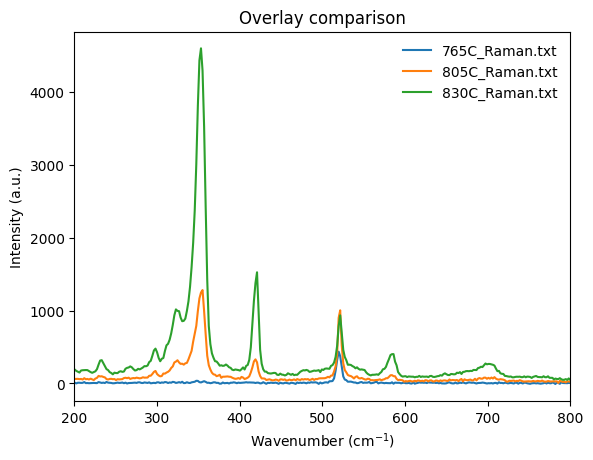

In [1]:
from ramanpl.batch import load_spectra, plot_overlay

files = [
    "765C_Raman.txt",
    "805C_Raman.txt",
    "830C_Raman.txt",
]

specs = load_spectra(files, axis="wavenumber")  # or axis="energy" for PL data
fig, ax = plot_overlay(specs, normalise="none", title="Overlay comparison", x_range=(200, 800))


You can also plot them in a waterfall style:

```python
        from ramanpl.batch import plot_waterfall
        files = [
            "path/to/point1.txt",
            "path/to/point2.txt",
            "path/to/point3.txt",
            "path/to/point4.txt",
        ]

        specs = load_spectra(files, axis="wavenumber")  # or axis="energy"
        fig, ax = plot_waterfall(specs, 
        normalise="max", 
        offset=1.0,         # vertical offset between spectra
        title="Waterfall comparison", 
        xlim=(200, 800)        # set x-axis limits
        )
```

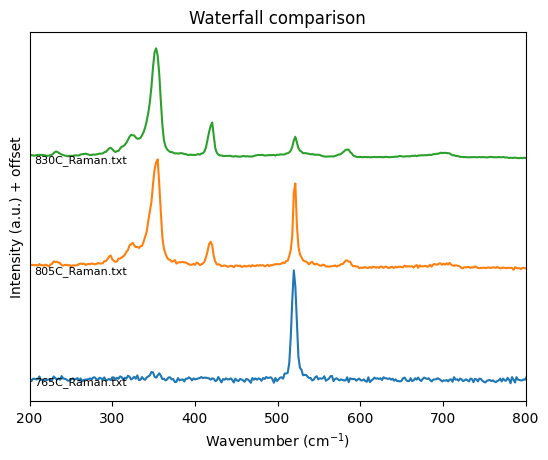

In [2]:
from ramanpl.batch import plot_waterfall

fig, ax = plot_waterfall(specs, normalise="max", offset=1.0, title="Waterfall comparison", xlim=(200, 800))


### Example of fitted plots

You can also overlay the fitted curves along with the raw data by setting the `y_select` parameter to `"fit"` or `"raw+fit"` in the `plot_overlay` function. But it will need to be done by importing the class modules `RamanBatch`:

```python
    from ramanpl.batch import RamanBatch
    
    files = [
            "path/to/point1.txt",   # or .wdf
            "path/to/point2.txt",
            "path/to/point3.txt",
            "path/to/point4.txt",
            ]

    specs = load_spectra(files, axis="wavenumber")

    b = RamanBatch(
        files,
        materials=["WS2"],      # specify the material for fitting, e.g. "WS2", "MoS2", etc.
        substrate="Si",         # specify substrate for background
        background_remove=True,
        baseline_method="arPLS",
    )

    b.fit()
    b.plot_overlay(normalise="max", raw_fit=True, title="Raman: raw + fit")
    b.plot_waterfall(normalise="max", raw_fit=True, offset=0.6, title="Raman waterfall")

```

D:\OneDrive - University of Cambridge\9 Expt results\Raman\00A_data_analysis_source code\RamanPL_2D\src\ramanpl\RamanFit.py:189: FutureWarning: 
Using 'baseline_method="arpls"' together with legacy parameters (poly_degree / gaussian_sigma) is deprecated and will be removed in a future version.
Please use:
  baseline_method=("arpls", value)
or:
  baseline_method={'method': 'arpls', 'param': value}
  method, bkwargs = BaselineAPI.parse_spec(
D:\OneDrive - University of Cambridge\9 Expt results\Raman\00A_data_analysis_source code\RamanPL_2D\src\ramanpl\baselineAPI.py:438: RuntimeWarning: overflow encountered in exp
  w = 1.0 / (1.0 + np.exp(2.0 * (d - (2.0 * sigma - mu)) / sigma))


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Raman waterfall'}, xlabel='Wavenumber (cm$^{-1}$)', ylabel='Intensity (a.u.) + offset'>)

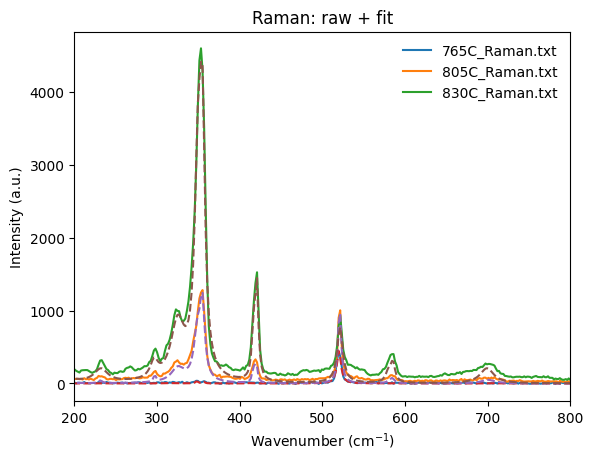

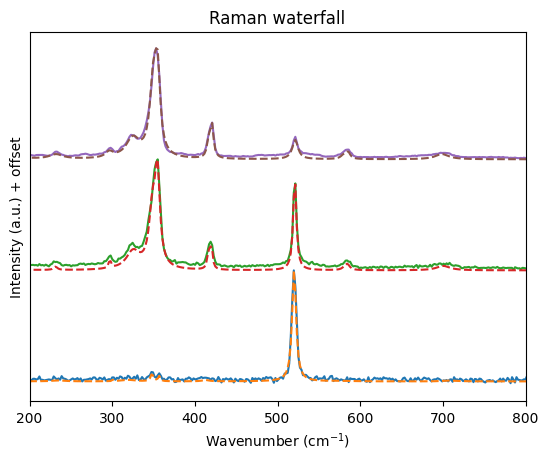

In [3]:
from ramanpl.batch import RamanBatch

files = ["765C_Raman.txt", "805C_Raman.txt", "830C_Raman.txt"]

b = RamanBatch(
    files,
    materials=["WS2"],
    substrate="Si",
    background_remove=True,
    baseline_method="arPLS",
)

b.fit()
b.plot_overlay(normalise="none", raw_fit=True, title="Raman: raw + fit",x_range=(200, 800))
b.plot_waterfall(normalise="max", raw_fit=True, offset=1.0, title="Raman waterfall",x_range=(200, 800))



And a more user-friendly display would be the *"wide"* tables. You can do it by the code such as this:

**(RECOMENDED)** Use the class module:

```python
    from ramanpl.batch import RamanBatch, pivot_parameters

    b = RamanBatch(...)  # as above

     wide = b.wide_table()

```

Or use the function `pivot_parameters` directly:

```python
    from ramanpl.batch import pivot_parameters

    wide = pivot_parameters(df)   # df = parameters_dataframe(rows)
    wide
```

In [5]:
import re

# Optional: add temperature column parsed from filename
def parse_temp(s):
    m = re.search(r"(\d+)\s*C", str(s))
    return float(m.group(1))

wide = b.wide_table(add_condition=True, 
                    condition_name="temperature_C",     # name of new column
                    condition=parse_temp,   # name of function to parse from source 
                    sort_by_condition=True              # sort by new column
                    )
wide

,2LA(M)-2E22g_fwhm,2LA(M)-2E22g_intensity,2LA(M)-2E22g_position,2LA(M)-E22g_fwhm,2LA(M)-E22g_intensity,2LA(M)-E22g_position,2LA(M)_fwhm,2LA(M)_intensity,2LA(M)_position,3LA(K)_fwhm,...,E12g_fwhm,E12g_intensity,E12g_position,LA(M)_fwhm,LA(M)_intensity,LA(M)_position,Si_fwhm,Si_intensity,Si_position,temperature_C
source,,,,,,,,,,,,,,,,,,,,,
765C_Raman.txt,0.062411,3789.336647,300.922487,20.000000,5.980508,319.488117,4.103351,29.781585,348.135740,10.000000,...,3.182293,20.279615,356.885007,20.000000,3.784446,174.494827,5.736914,454.302987,520.044289,765.0
805C_Raman.txt,3.272217,90.603385,297.176844,19.957633,197.195364,325.194776,10.000000,632.239604,348.713507,5.932040,...,6.931254,987.256962,354.685003,14.715274,69.193997,174.830472,4.585711,1046.184534,520.834090,805.0
830C_Raman.txt,10.963459,231.599262,296.464944,20.000000,778.887158,324.895245,10.000000,2875.980242,349.650291,8.057841,...,7.124225,2987.545283,354.883702,20.000000,287.809911,175.521825,8.185597,772.394199,521.313131,830.0


### Data export
**(Recomended)** You can use class module ways again, cleanly:

```python
    from ramanpl.batch import RamanBatch

    b = RamanBatch(...)  # as above

    b.export("filename.csv")

```

Or you can even export the fitted data and metadata to CSV or TXT files using the `export_dataframe` function:

```python
    from ramanpl.batch import pivot_parameters, export_table
    export_table(
        wide,
        "raman_fit_wide.csv",
        fits_with_fitters=fits,
        metadata={"x_axis": "your_x_axis_info"}, # such as units or experimental conditions
        meta_in_csv=True,       # write # comment metadata even in CSV
        float_format="%.6g",
    )

```

In [6]:

b.export("raman_fit_wide.csv", 
         wide=True, 
         add_condition=True, 
         condition=parse_temp
         )


'raman_fit_wide.csv'

### Example of plot for fitted paramter plots
Next, you can use the fitted parameters to plot the change in the Raman peak positions, FWHM, and intensities across different samples:

1. Default: x-axis = file names (no condition needed)

```python
    from ramanpl.batch import plot_fitted_parameters
    import pandas as pd
    
    df_r = b_raman.to_dataframe()   # pandas DataFrame created internally

    # Position
    plot_fitted_parameters(
        df_r,
        metric="position",          # or "fwhm", "intensity"
        peaks=["E12g", "A1g"],
        title="Raman peak positions",
        ylabel="Position (cm$^{-1}$)",
    )
```

2. Alternatively, you can define x-axis condition (e.g. temperature) by providing a list/array of conditions (most beginner-friendly)

```python
    temps = [765, 805, 830]
    b_raman.plot_parameters(
        metric="intensity",
        peaks=["E12g", "A1g"],
        x=temps,
        x_label="Temperature (°C)",
        title="Raman intensity vs temperature",
    )

```

3. Or provide a function (power-user / pattern-based)
```python
    def pressure_from_name(src: str):
    # user-defined parsing logic
    ...

    b_pl.plot_parameters(metric="fwhm", peaks=["exciton","trion"], x=pressure_from_name,
                     x_label="Pressure (mbar)", title="PL FWHM vs pressure")
```



(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Raman FWHM vs Temperature'}, xlabel='Condition', ylabel='FWHM (cm$^{-1}$)'>)

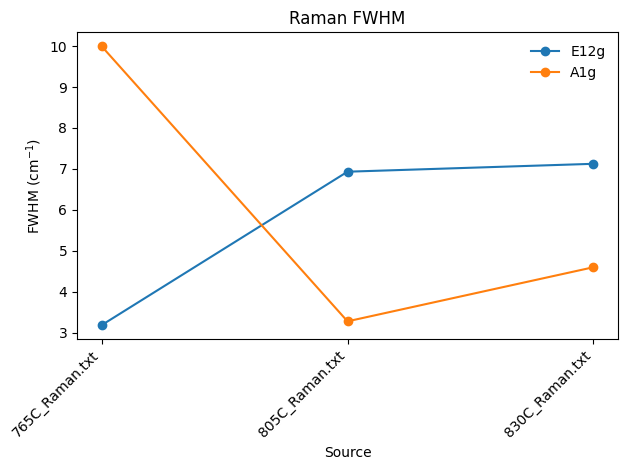

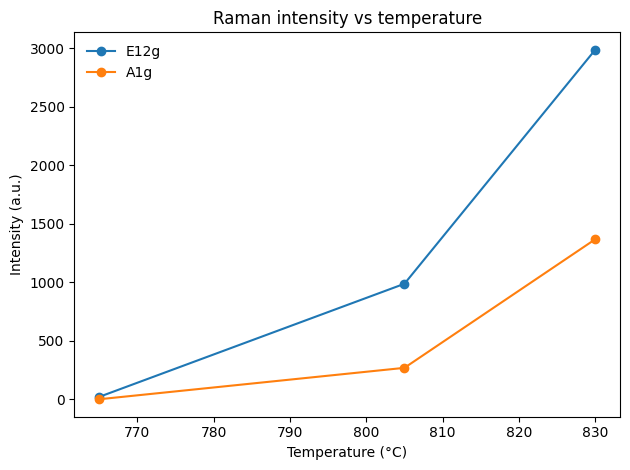

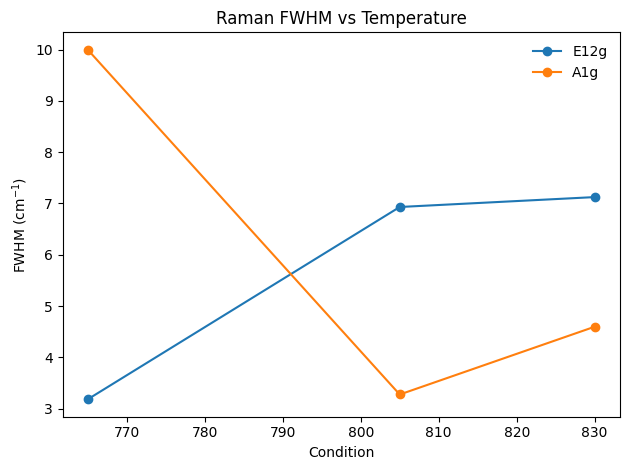

In [7]:
from ramanpl.batch import plot_fitted_parameters

# Run b.fit() first as above

# Directly plot from RamanBatch object
b.plot_parameters(metric="fwhm", peaks=["E12g", "A1g"], title="Raman FWHM")


## Alternatively, you can define x-axis condition (e.g. temperature)
temps = [765, 805, 830]
b.plot_parameters(
    metric="intensity",
    peaks=["E12g", "A1g"],
    x=temps,
    x_label="Temperature (°C)",
    title="Raman intensity vs temperature",
)


# Or plot from a user-defined logic
import re

def cond_from_source(s):
    # Example: "765C_Raman.txt" -> 765
    m = re.search(r"(\d+)\s*C", str(s))
    if not m:
        raise ValueError(f"Cannot parse condition from source: {s}")
    return float(m.group(1))

b.plot_parameters(metric="fwhm", peaks=["E12g","A1g"], x=cond_from_source,
                     x_label="Temperature (°C)", title="Raman FWHM vs Temperature")

--------
## PL example

In the following example, we will demonstrate the plotting of WS2 photoluminescence spectra collected from different morphologies fabricated under various temperature conditions.

Expt setting:
- Sampling site: same as Raman
- Exposure time: 0.1s
- Laser Power: 1%
- magnification: 100x
- Accumulation: 3
- Central wavelength: 1.93eV
- Laser setting: `532nm` ; grating: `1800 vis`

### Example of plotting

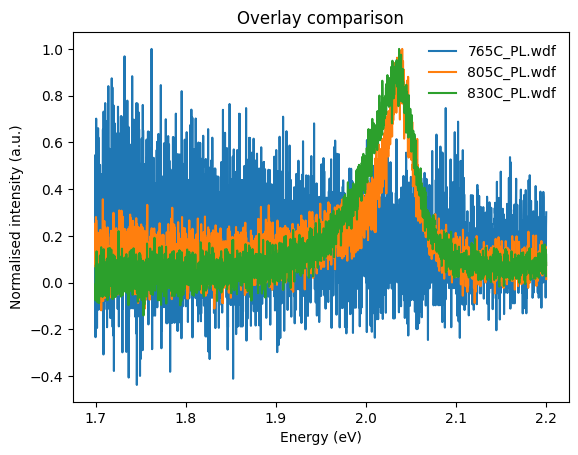

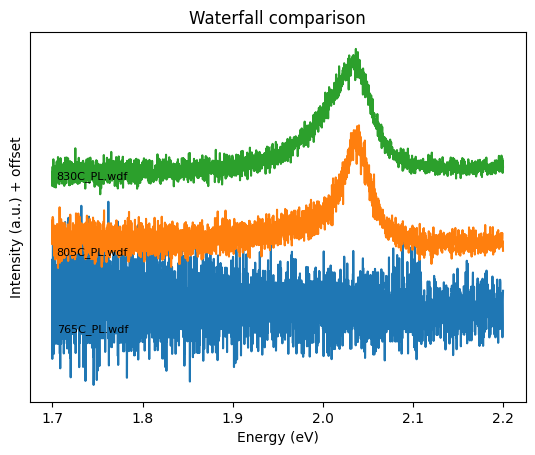

In [8]:
### Overlay plot for PL data
from ramanpl.batch import load_spectra, plot_overlay

files = [
    "765C_PL.wdf",
    "805C_PL.wdf",
    "830C_PL.wdf",
]

specs = load_spectra(files, axis="energy")
fig, ax = plot_overlay(specs, normalise="max", title="Overlay comparison")


### waterfall plot
from ramanpl.batch import plot_waterfall

fig1, ax1= plot_waterfall(specs, normalise="max", offset=0.6, title="Waterfall comparison")


### Example of fitted plots
**(Recomended)** You can fit the PL spectra using the `PLBatch` class module:

```python
    from ramanpl.batch import PLBatch

    files = [
            "path/to/point1.wdf",
            "path/to/point2.wdf",
            "path/to/point3.wdf",
            "path/to/point4.wdf",
        ]

    b = PLBatch(
        files,
        background_remove=True,
        baseline_method="arPLS",
        smoothing=False,
    )

    b.fit()
    b.plot_overlay(normalise="max", raw_fit=True, title="PL: raw + fit")
    b.plot_waterfall(normalise="max", raw_fit=True, offset=1.0, title="PL waterfall")

```


Or you can also plot fitted curve of the PL spectra in an overlay style:

```python
        from ramanpl.batch import load_spectra, plot_overlay

        files = [
            "path/to/point1.wdf",
            "path/to/point2.wdf",
            "path/to/point3.wdf",
            "path/to/point4.wdf",
        ]

        specs = load_spectra(files, axis="energy")  # or axis="wavenumber" for Raman data
        fig, ax = plot_overlay(specs, normalise="max", title="Overlay comparison")
```


D:\OneDrive - University of Cambridge\9 Expt results\Raman\00A_data_analysis_source code\RamanPL_2D\src\ramanpl\PLfit.py:117: FutureWarning: 
Using 'baseline_method="arpls"' together with legacy parameters (poly_degree / gaussian_sigma) is deprecated and will be removed in a future version.
Please use:
  baseline_method=("arpls", value)
or:
  baseline_method={'method': 'arpls', 'param': value}
  method, bkwargs = BaselineAPI.parse_spec(


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'PL: raw + fit'}, xlabel='Energy (eV)', ylabel='Normalised intensity (a.u.)'>)

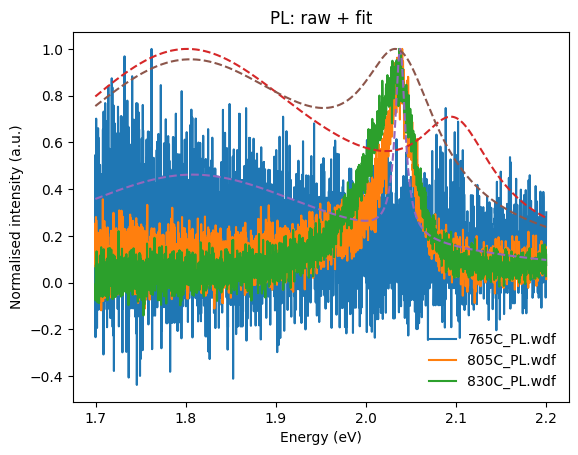

In [9]:
from ramanpl.batch import PLBatch

files = ["765C_PL.wdf", "805C_PL.wdf", "830C_PL.wdf"]

b_pl = PLBatch(
    files,
    background_remove=True,
    baseline_method="arPLS",
    smoothing=False,
)

b_pl.fit()     ## perform fitting
b_pl.plot_overlay(normalise="max", raw_fit=True, title="PL: raw + fit")

**(Optional)** You can also view your wide table or export the data as per Raman example aboove:

```python
    from ramanpl.batch import PLBatch
    b = PLBatch(...)  # as above
    b.export("pl_fitted_paramters.csv")
```

### Example of plot for fitted paramter plots

Similarly, you can plotted fitted parameters such as peak positions, FWHM, and intensities across different samples using the `plot_fitted_parameters` function.
```python
    from ramanpl.batch import plot_fitted_parameters

    # b_pl is your PLBatch instance, already fitted:
    # b_pl.fit()

    temps = [765, 805, 830]
    b_pl.plot_parameters(
    metric="intensity",
    peaks=["exciton", "trion"],
    x=temps,
    x_label="Temperature (°C)",
    title="PL intensity vs temperature",
    )
```


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'PL intensity vs temperature'}, xlabel='Temperature (°C)', ylabel='Intensity (a.u.)'>)

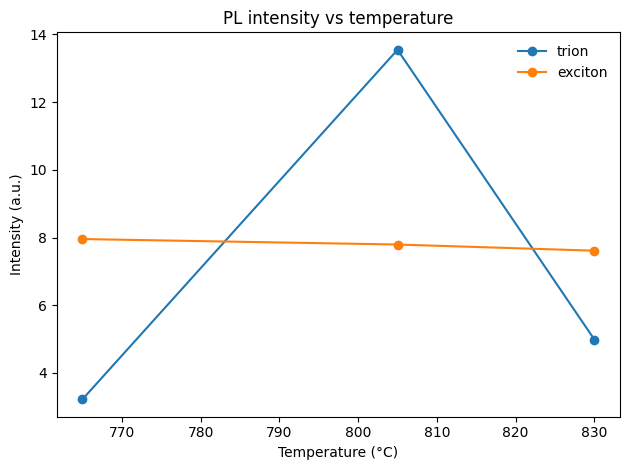

In [10]:

from ramanpl.batch import plot_fitted_parameters

# b_pl is your PLBatch instance, already fitted:
# b_pl.fit()

temps = [765, 805, 830]
b_pl.plot_parameters(
metric="intensity",
peaks=["exciton", "trion"],
x=temps,
x_label="Temperature (°C)",
title="PL intensity vs temperature",
)
